# DS 4400 - Assignment 04

**Student Name**: Elyssa Querubin

**Date**: 3/26/26


### Submission Instructions
- Submit a PDF writeup named `%LASTNAME%_HW4.pdf` in Gradescope. Please answer all the questions in the PDF. If a problem asks for graphs or other results, please extract the results from the code and include them in the report. The PDF report should have complete answers to all the questions.
- The problem set contains two types of problem as noted at the beginning of the question or sub-question: (1) analytical, denoted by *[A]*; **and (2) computational, denoted by *[C]*. The response to analytical problems should show all works and derivations. The response to computational problems should contain expected results, and the code should be made available.
- Please use Jupyter notebooks in Python as we will be selectively running your code. Include comments in the code if needed. Include a link to your code in the PDF file.

### Course policy on collaboration and cheating

- You may discuss the concepts with your classmates, but write up the answers entirely on your own.
- You cannot share your code with your classmates.
- You cannot use code from the Internet or entirely generated with AI for your assignment.
- You can post questions on Piazza and are encouraged to come to the TA and Instructor office hours.

### Dataset

The datasets for this assignment are: 

- The *SPAMBASE* dataset from the UCI repository available at [here](https://archive.ics.uci.edu/dataset/94/spambase). The first 57 columns are features counting word frequencies (see documentation [here](https://archive.ics.uci.edu/ml/machine-learning-databases/spambase/spambase.names)). The last column indicates `1` for the `SPAM` class and `0` for the `HAM` class.
- The Mushroom dataset from the UCI repository available [here](https://archive.ics.uci.edu/dataset/73/mushroom). This dataset consists of 22 categorical attributes, and the
prediction task is whether the mushroom is edible or poisonous. The class label is the first column in the dataset.

In [1]:
pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


In [2]:
from ucimlrepo import fetch_ucirepo 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

In [3]:

# fetch dataset 
spambase = fetch_ucirepo(id=94) 
  
# data (as pandas dataframes) 
X = spambase.data.features 
y = spambase.data.targets.values.ravel() 
  
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## Problem 1: Decision Trees (25 points)

1. Use an existing package to train a decision tree on the *SPAMBASE* training data, without pruning. Use the information gain splitting criteria. Compute the training and the testing error, accuracy, F1 score, and AUC and report these metrics. Write down some observations about the training and testing metrics.
2. Change the splitting criteria to use the Gini index. and report the same metrics. Compare them to the information gain metrics.
3. Implement a pruning criteria that sets an upper bound on the maximum depth of the tree. Generate a graph that plots the training and
testing error as a function of the tree depth on the *SPAMBASE* data. Please explain your observations. What is the optimal depth of the
tree that you would recommend based on this analysis?

In [4]:
# helper for printing metrics
def report(clf, label):
    y_tr   = clf.predict(X_train)
    y_te   = clf.predict(X_test)
    y_prob = clf.predict_proba(X_test)[:, 1]
    print(f"\n{label} (depth={clf.get_depth()})")
    print(f"  Train Error: {1-accuracy_score(y_train,y_tr):.4f}  Train Acc: {accuracy_score(y_train,y_tr):.4f}  Train F1: {f1_score(y_train,y_tr):.4f}")
    print(f"  Test  Error: {1-accuracy_score(y_test,y_te):.4f}  Test  Acc: {accuracy_score(y_test,y_te):.4f}  Test  F1: {f1_score(y_test,y_te):.4f}  AUC: {roc_auc_score(y_test,y_prob):.4f}")


Information Gain (Entropy) (depth=25)
  Train Error: 0.0005  Train Acc: 0.9995  Train F1: 0.9993
  Test  Error: 0.0684  Test  Acc: 0.9316  Test  F1: 0.9176  AUC: 0.9286

Gini Index (depth=25)
  Train Error: 0.0005  Train Acc: 0.9995  Train F1: 0.9993
  Test  Error: 0.0814  Test  Acc: 0.9186  Test  F1: 0.9020  AUC: 0.9176

Optimal depth: 15  |  Min test error: 0.0630


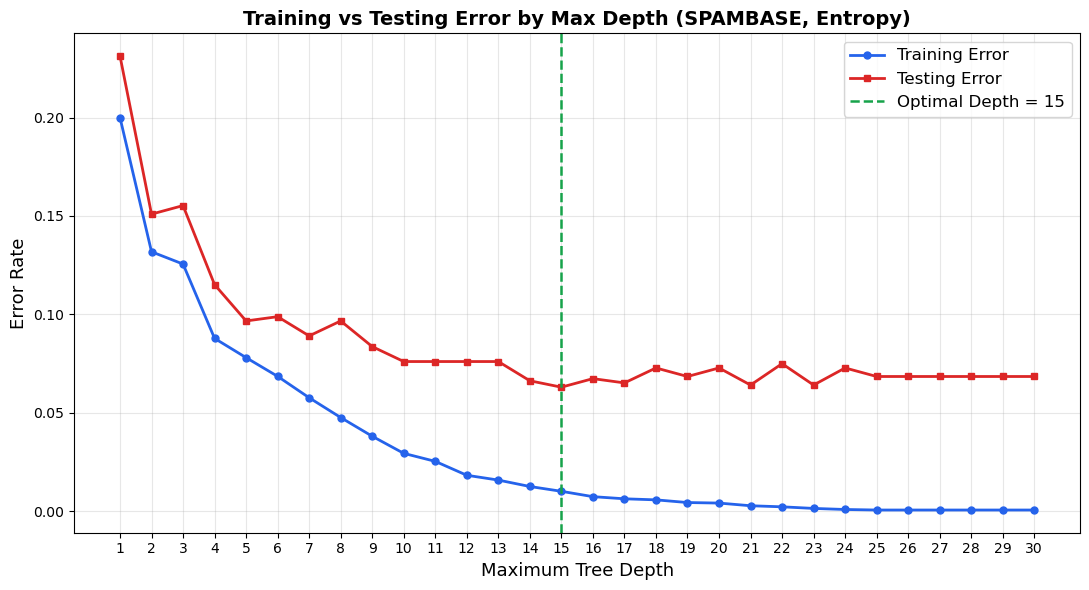

In [5]:
# decision tree with sklearn
dt_entropy = DecisionTreeClassifier(criterion="entropy", random_state=42).fit(X_train, y_train)
report(dt_entropy, "Information Gain (Entropy)")

# 2. gini index
dt_gini = DecisionTreeClassifier(criterion="gini", random_state=42).fit(X_train, y_train)
report(dt_gini, "Gini Index")

# 3. max depth + graph
depths = range(1, 31)
train_errors, test_errors = [], []
 
for d in depths:
    clf = DecisionTreeClassifier(criterion="entropy", max_depth=d, random_state=42).fit(X_train, y_train)
    train_errors.append(1 - accuracy_score(y_train, clf.predict(X_train)))
    test_errors.append( 1 - accuracy_score(y_test,  clf.predict(X_test)))
 
opt = list(depths)[np.argmin(test_errors)]
print(f"\nOptimal depth: {opt}  |  Min test error: {min(test_errors):.4f}")
 
fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(list(depths), train_errors, "o-", color="#2563EB", label="Training Error", lw=2, ms=5)
ax.plot(list(depths), test_errors,  "s-", color="#DC2626", label="Testing Error",  lw=2, ms=5)
ax.axvline(x=opt, color="#16A34A", linestyle="--", lw=1.8, label=f"Optimal Depth = {opt}")
ax.set_xlabel("Maximum Tree Depth", fontsize=13)
ax.set_ylabel("Error Rate", fontsize=13)
ax.set_title("Training vs Testing Error by Max Depth (SPAMBASE, Entropy)", fontsize=14, fontweight="bold")
ax.legend(fontsize=12)
ax.set_xticks(list(depths))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("decision_tree_depth_error.png", dpi=150, bbox_inches="tight")
plt.show()

### Please explain your observations: Write down some observations about the training and testing metrics, Compare them to the information gain metrics, What is the optimal depth of the tree that you would recommend based on this analysis?

Entropy performs better than gini on every test metric, lower error (6% vs 8%), higher F1 (0.92 vs 0.90), and higher AUC (0.93 vs 0.92).

Both entropy and gini perform at the same level for training, but drop downwards for testing, showing overfitting.

The optimal depth, based on the results within the graph, would be 15 where it minimizes test error by about 6.3%, slightly better than 6.84 in the tree without pruning (6.8%). Above 15 the tree continues fitting noise (overfitting) within the training data, and below the tree is too shallow (underfitting).

## Problem 2: Random Forest Ensemble (25 points)

1. Use an existing package to train a Random Forest ensemble with 10, 50, 100, and 500 decision trees on the *SPAMBASE* dataset. Report
accuracy, F1 score, and AUC on both the training and testing sets for $T \in \{10, 50, 100, 500\}$. How do the metrics change as $T$
increases?
2. Compare the metrics obtained for Random Forest with the Decision tree metrics obtained in Problem 1. Write down some observations.
3. Compute the variable importance for each feature and include a plot.

In [6]:
from sklearn.ensemble import RandomForestClassifier
# 1. random forest

T_values = [10, 50, 100, 500]
 
for T in T_values:
    rf = RandomForestClassifier(n_estimators=T, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
 
    y_tr   = rf.predict(X_train)
    y_te   = rf.predict(X_test)
    y_prob = rf.predict_proba(X_test)[:, 1]
 
    print(f"\nRandom Forest (T={T})")
    print(f"  Train Acc: {accuracy_score(y_train,y_tr):.4f}  Train F1: {f1_score(y_train,y_tr):.4f}")
    print(f"  Test  Acc: {accuracy_score(y_test,y_te):.4f}  Test  F1: {f1_score(y_test,y_te):.4f}  AUC: {roc_auc_score(y_test,y_prob):.4f}")


Random Forest (T=10)
  Train Acc: 0.9946  Train F1: 0.9929
  Test  Acc: 0.9403  Test  F1: 0.9262  AUC: 0.9745

Random Forest (T=50)
  Train Acc: 0.9995  Train F1: 0.9993
  Test  Acc: 0.9490  Test  F1: 0.9377  AUC: 0.9834

Random Forest (T=100)
  Train Acc: 0.9995  Train F1: 0.9993
  Test  Acc: 0.9555  Test  F1: 0.9458  AUC: 0.9851

Random Forest (T=500)
  Train Acc: 0.9995  Train F1: 0.9993
  Test  Acc: 0.9577  Test  F1: 0.9485  AUC: 0.9857


### How do the metrics change as T increases? Compare the metrics obtained for Random Forest with the Decision tree metrics obtained in Problem 1. Write down some observations.

As T increases, test metrics improve steadily but with diminishing returns after T = 100, this jump from 100 to 500 suggests the ensemble has converged. Training metrics stabilize at 0.9995 accuracy and 0.9993 F1 from T = 50 onwards.

Random Forest outperforms the single decision tree across every test metric at every value of T. The AUC improvement is also quite large (0.9857 vs 0.9286), because averaging many trees reduces the variance that caused the single tree to overfit.


Feature Importances Top 20
   1. char_freq_!                         0.1177
   2. char_freq_$                         0.0989
   3. word_freq_remove                    0.0806
   4. capital_run_length_average          0.0637
   5. word_freq_free                      0.0622
   6. capital_run_length_longest          0.0560
   7. word_freq_your                      0.0553
   8. capital_run_length_total            0.0468
   9. word_freq_hp                        0.0423
  10. word_freq_money                     0.0339
  11. word_freq_our                       0.0316
  12. word_freq_you                       0.0306
  13. word_freq_000                       0.0266
  14. word_freq_george                    0.0216
  15. word_freq_hpl                       0.0177
  16. word_freq_edu                       0.0166
  17. word_freq_internet                  0.0137
  18. word_freq_business                  0.0126
  19. char_freq_(                         0.0123
  20. word_freq_will                     

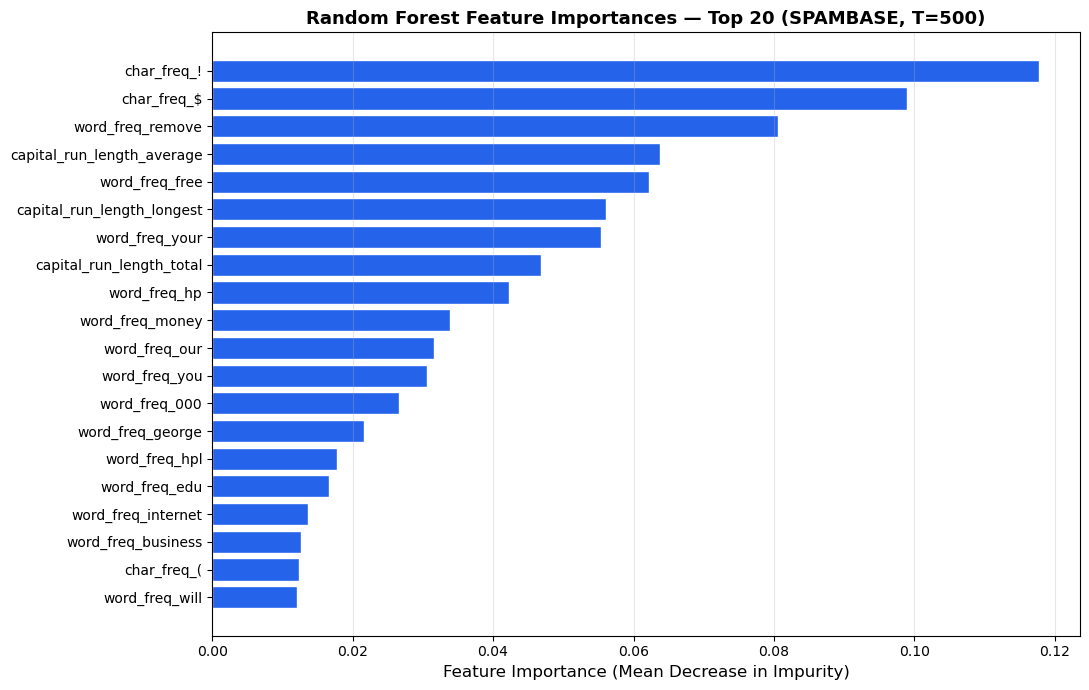

In [7]:
# 3. variable importance
rf_best = RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1)
rf_best.fit(X_train, y_train)
 
importances = rf_best.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[::-1]
 
# ranked features
print("\nFeature Importances Top 20")
for i in range(20):
    print(f"  {i+1:2d}. {feature_names[indices[i]]:<35} {importances[indices[i]]:.4f}")
 
# top 20 features
top_n = 20
fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(
    range(top_n),
    importances[indices[:top_n]][::-1],
    color="#2563EB", edgecolor="white"
)
ax.set_yticks(range(top_n))
ax.set_yticklabels([feature_names[indices[top_n - 1 - i]] for i in range(top_n)], fontsize=10)
ax.set_xlabel("Feature Importance (Mean Decrease in Impurity)", fontsize=12)
ax.set_title("Random Forest Feature Importances — Top 20 (SPAMBASE, T=500)", fontsize=13, fontweight="bold")
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

## Problem 3: AdaBoost Ensemble (25 points)

1. Use an existing package to train an AdaBoost ensemble with 10, 50, 100, and 500 base classifiers on the *SPAMBASE* dataset. Use a
decision tree classifier as the base classification model. Report accuracy, F1 score, and AUC on both the training and testing sets.
2. Compare AdaBoost with the Random Forest ensemble for 10, 50, 100, and 500 base learners by looking at various metrics on the training
and testing sets.
3. Plot the ROC curves for the decision tree model, Random Forest with 100 trees, and AdaBoost with 100 trees.

In [8]:
from sklearn.ensemble import AdaBoostClassifier

# 1. adaboost ensemble

# set t values
T_values = [10, 50, 100, 500]
 
for T in T_values:
    # train adaboost ensample
    ada = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1),
        n_estimators=T,
        random_state=42
    )
    ada.fit(X_train, y_train)

    # predict
    y_tr = ada.predict(X_train)
    y_te = ada.predict(X_test)
    y_prob = ada.predict_proba(X_test)[:, 1]

    # print metrics
    print(f"\nAdaBoost (T={T})")
    print(f"  Train Acc: {accuracy_score(y_train,y_tr):.4f}  Train F1: {f1_score(y_train,y_tr):.4f}")
    print(f"  Test  Acc: {accuracy_score(y_test,y_te):.4f}  Test  F1: {f1_score(y_test,y_te):.4f}  AUC: {roc_auc_score(y_test,y_prob):.4f}")


AdaBoost (T=10)
  Train Acc: 0.9060  Train F1: 0.8769
  Test  Acc: 0.8947  Test  F1: 0.8729  AUC: 0.9631

AdaBoost (T=50)
  Train Acc: 0.9342  Train F1: 0.9139
  Test  Acc: 0.9262  Test  F1: 0.9103  AUC: 0.9776

AdaBoost (T=100)
  Train Acc: 0.9408  Train F1: 0.9220
  Test  Acc: 0.9370  Test  F1: 0.9237  AUC: 0.9811

AdaBoost (T=500)
  Train Acc: 0.9516  Train F1: 0.9368
  Test  Acc: 0.9501  Test  F1: 0.9403  AUC: 0.9830


### Compare AdaBoost with the Random Forest ensemble for 10, 50, 100, and 500 base learners by looking at various metrics on the training and testing sets.

As T increased so did both test and training accuracy and F1 scores for both random forest and adaboost. Random forest outperforms Adaboost in every T value for both training and testing metrics. Random forest achieved at T=10 0.9946 then stabilized to 0.9995 after. At T=500 Random forest achieves the highest test accuracy with 0.9577 vs AdaBoost at 0.9501. After T=50, Random Forest improves only marginally, in comparison AdaBoost continues to improve after T=100, which suggests that it hasn't fully converged yet and may close the gap further the more T grows.

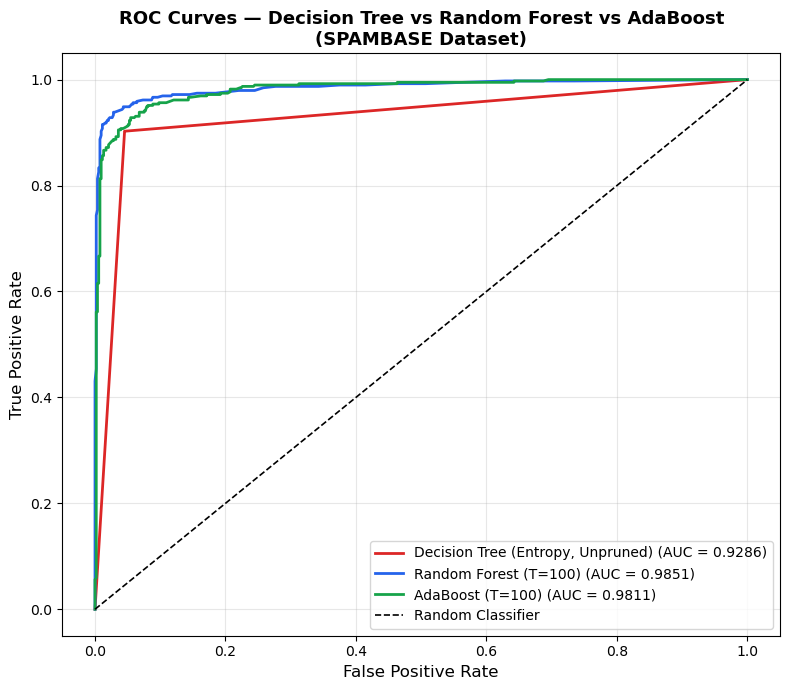

In [9]:
from sklearn.metrics import roc_curve

# 3. plot

# decision tree entropy
dt = DecisionTreeClassifier(criterion="entropy", random_state=42)
dt.fit(X_train, y_train)
 
# rand forest T=100
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
 
# adaboost T=100
ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100,
    random_state=42
)
ada.fit(X_train, y_train)
 
models = [
    (dt,  "Decision Tree (Entropy, Unpruned)", "#DC2626"),
    (rf,  "Random Forest (T=100)",             "#2563EB"),
    (ada, "AdaBoost (T=100)",                  "#16A34A"),
]

# plot
fig, ax = plt.subplots(figsize=(8, 7))
for model, label, color in models:
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, color=color, lw=2, label=f"{label} (AUC = {auc:.4f})")
 
ax.plot([0, 1], [0, 1], "k--", lw=1.2, label="Random Classifier")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curves — Decision Tree vs Random Forest vs AdaBoost\n(SPAMBASE Dataset)", fontsize=13, fontweight="bold")
ax.legend(fontsize=10, loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Problem 4: Naive Bayes classifier (25 points)

In this problem you will implement your own Naive Bayes classifier and you will compare it with a package implementation. You will use the
Mushroom dataset for this problem. Split the dataset into 75% for training and 25% for testing.

1. Train the Naive Bayes classifier. Compute the prior probabilities for the `*Edible*` and `*Poisonous*` classes from the training data. For each feature $X_i$ in the dataset compute the probabilities $P[X_i = x| Y=\textit{Edible}]$, and $P[X_i = x| Y=\textit{Poisonous}]$ from the training data. Use the Laplace smoothing method when computing these probabilities. Note that the Naive Bayes classifier stores these prior and conditional probabilities.
2. For each point in the testing set estimate the probability that it belongs to the `*Edible*` and `*Poisonous*` classes. Use the Naive Bayes
classifier probabilities computed in part (1).
3. Compute accuracy, precision, recall, and F1 score for your Naive Bayes classifier on the testing data.
4. Compare the results obtained by your implementation with those obtained with a Naive Bayes package (trained on the same dataset).
Use several metrics, including accuracy, precision, recall, and F1 score. Are the results similar or different?

In [10]:
# get the mushroom dataset
mushroom = fetch_ucirepo(id=73)
X = mushroom.data.features
y = mushroom.data.targets.values.ravel()  
# p = poisonous e = edible

# take care of nans
mask = ~X.isna().any(axis=1)
X = X[mask]
y = y[mask]
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

In [11]:
# naive bayes classifier from scratch
class NaiveBayesClassifier:

    # computes and stores probablities needed (like model.fit in python)
    def fit(self, X, y):
        # count edible vs poisoin
        self.classes_, counts = np.unique(y, return_counts=True)
        n = len(y)
 
        # prior probs P(Y)
        self.priors = {c: count / n for c, count in zip(self.classes_, counts)}
 
        # cond probs P(Xi = x | Y = c) w/ laplace smoothing
        self.cond_probs = {}
        for c in self.classes_:
            self.cond_probs[c] = {}
            X_c = X[y == c]
            
            for col in X.columns:
                all_vals = X[col].unique()
                val_counts = X_c[col].value_counts().to_dict()
                # total edible
                n_c = len(X_c)
                k = len(all_vals)
                
                self.cond_probs[c][col] = {
                    # laplace smoothing
                    v: (val_counts.get(v, 0) + 1) / (n_c + k)
                    for v in all_vals
                }
        return self
 
    def predict_proba(self, X):
        probs = []

        # loop over each test mush
        for _, row in X.iterrows():
            class_scores = {}

            # check edible and poison
            for c in self.classes_:
                # log probabilities to avoid underflow
                log_prob = np.log(self.priors[c])

                # loop over features
                for col in X.columns:
                    val = row[col]
                    # if unseen value, use smoothed fallback
                    p = self.cond_probs[c][col].get(val, 1 / (len(self.cond_probs[c][col]) + 1))
                    log_prob += np.log(p)

                # store final score for class
                class_scores[c] = log_prob 
 
            # convert log probs to norm probs
            max_score = max(class_scores.values())
            exp_scores = {c: np.exp(s - max_score) for c, s in class_scores.items()}
            total = sum(exp_scores.values())
            probs.append({c: exp_scores[c] / total for c in self.classes_})
        return probs
 
    def predict(self, X):
        # get probs for each class
        proba = self.predict_proba(X)
        # pick class w/ highest prob
        return np.array([max(p, key=p.get) for p in proba])


In [12]:
# train custom nb

# initialize
nb_custom = NaiveBayesClassifier()
nb_custom.fit(X_train, y_train)

print("Prior Probabilities")
for c, p in nb_custom.priors.items():
    label = "Edible" if c == "e" else "Poisonous"
    print(f"  P(Y = {label}): {p:.4f}")
 
first_col = X.columns[0]
print(f"\nConditional Probabilities for '{first_col}'")
for c in nb_custom.classes_:
    label = "Edible" if c == "e" else "Poisonous"
    print(f"  Y = {label}:")
    for val, prob in nb_custom.cond_probs[c][first_col].items():
        print(f"    P({first_col} = {val:>2} | {label}) = {prob:.4f}")

Prior Probabilities
  P(Y = Edible): 0.6145
  P(Y = Poisonous): 0.3855

Conditional Probabilities for 'cap-shape'
  Y = Edible:
    P(cap-shape =  x | Edible) = 0.4975
    P(cap-shape =  f | Edible) = 0.4135
    P(cap-shape =  k | Edible) = 0.0058
    P(cap-shape =  b | Edible) = 0.0740
    P(cap-shape =  s | Edible) = 0.0088
    P(cap-shape =  c | Edible) = 0.0004
  Y = Poisonous:
    P(cap-shape =  x | Poisonous) = 0.5171
    P(cap-shape =  f | Poisonous) = 0.4493
    P(cap-shape =  k | Poisonous) = 0.0092
    P(cap-shape =  b | Poisonous) = 0.0208
    P(cap-shape =  s | Poisonous) = 0.0006
    P(cap-shape =  c | Poisonous) = 0.0031


In [13]:
from sklearn.metrics import precision_score, recall_score
from sklearn.naive_bayes import CategoricalNB
from sklearn.preprocessing import OrdinalEncoder
# compute metrics

y_pred_custom = nb_custom.predict(X_test)
 
print("\nCustom Naive Bayes (Test Set)")
print(f"  Accuracy : {accuracy_score(y_test, y_pred_custom):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_custom, pos_label='p'):.4f}")
print(f"  Recall   : {recall_score(y_test, y_pred_custom, pos_label='p'):.4f}")
print(f"  F1 Score : {f1_score(y_test, y_pred_custom, pos_label='p'):.4f}")

# encode categorical feats as ints
enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
X_train_enc = enc.fit_transform(X_train)
X_test_enc  = enc.transform(X_test)

# with package sklearn for comparison
nb_sklearn = CategoricalNB()
nb_sklearn.fit(X_train_enc, y_train)
y_pred_sklearn = nb_sklearn.predict(X_test_enc)
 
print("\nSklearn Categorical Naive Bayes (Test Set)")
print(f"  Accuracy : {accuracy_score(y_test, y_pred_sklearn):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_sklearn, pos_label='p'):.4f}")
print(f"  Recall   : {recall_score(y_test, y_pred_sklearn, pos_label='p'):.4f}")
print(f"  F1 Score : {f1_score(y_test, y_pred_sklearn, pos_label='p'):.4f}")


Custom Naive Bayes (Test Set)
  Accuracy : 0.9667
  Precision: 0.9938
  Recall   : 0.9160
  F1 Score : 0.9533

Sklearn Categorical Naive Bayes (Test Set)
  Accuracy : 0.9667
  Precision: 0.9938
  Recall   : 0.9160
  F1 Score : 0.9533


### 4. Compare the results obtained by your implementation with those obtained with a Naive Bayes package (trained on the same dataset). Use several metrics, including accuracy, precision, recall, and F1 score. Are the results similar or different?

The package and my implementation produced identical metrics! This confirms that my implementation is correct.The Naive Bayes classifier performs well overall with high precision at 0.9938 meaning most mushrooms predicted as poisinous are. Recall is a bit lower at 0.9160 meaning a small number are incorrectly classified as edible.

## Helpful resources 
Don't forget to cite websites which helped you solve a problem in a unique way.  You can do this in markdown near the code or with a simple one-line comment inside the code cell, or you can list them below. 

You do not need to cite the official python documentation.


https://machinelearningmastery.com/naive-bayes-classifier-scratch-python/
https://codesignal.com/learn/courses/classification-algorithms-and-metrics/lessons/implementing-the-naive-bayes-classifier-from-scratch-in-python
https://www.geeksforgeeks.org/machine-learning/addressing-numerical-underflow-in-naive-bayes-classification/
https://www.geekhttps://www.geeksforgeeks.org/random-forest-classifier-using-scikit-learn/sforgeeks.org/random-forest-classifier-using-scikit-learn/
https://www.geeksforgeeks.org/machine-learning/building-and-implementing-decision-tree-classifiers-with-scikit-learn-a-comprehensive-guide/